# Latent Space Analysis


## Goal
Produce the strongest insight section in the project.

## Required outputs
- UMAP / T-SNE plots
- neighborhood purity
- outlier analysis
- semantic direction observations
- at least 5 report-ready insights

In [1]:
# Latent Space Analysis - Word2Vec focus
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest
import umap

# Setup project root
_CWD = Path.cwd().resolve()
_CANDIDATES = [_CWD, _CWD.parent]
PROJECT_ROOT = next(
    (p for p in _CANDIDATES if (p / "src").exists() and (p / "configs").exists()),
    _CWD,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.train_word2vec import (
    _read_yaml,
    apply_row_cap,
    build_config,
    enforce_category_scope,
    load_split,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 160)

# Directories
tables_dir = PROJECT_ROOT / "reports" / "tables"
figures_dir = PROJECT_ROOT / "reports" / "figures"
vectors_dir = PROJECT_ROOT / "artifacts" / "vectors"
metrics_dir = PROJECT_ROOT / "artifacts" / "metrics"

# Create output dirs if missing
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

# Load configuration and validation data
params = _read_yaml(PROJECT_ROOT / "params.yaml")
exp = _read_yaml(PROJECT_ROOT / "configs" / "word2vec.yaml")

# Get max_vector_rows from w2v_summary to match notebook 5's cap
w2v_summary = json.loads(
    (metrics_dir / "word2vec_skipgram_summary.json").read_text(encoding="utf-8")
)

class CLIStub:
    max_train_rows = w2v_summary["config"].get("max_train_rows")
    max_vector_rows = w2v_summary["config"].get("max_vector_rows")

cfg = build_config(params=params, exp=exp, cli=CLIStub())

# Load validation split (same as notebook 5)
val_df, val_text_column = load_split(
    PROJECT_ROOT / "data" / "processed" / "val.parquet",
    cfg.text_column,
)
val_df = apply_row_cap(
    enforce_category_scope(val_df, cfg=cfg, split_name="val"),
    max_rows=cfg.max_vector_rows,
    seed=cfg.seed,
).reset_index(drop=True)

print(f"Loaded validation set: {len(val_df)} rows")
print(f"Columns: {val_df.columns.tolist()}")

# Load Word2Vec vectors
vectors_path = vectors_dir / "word2vec_skipgram_val_vectors.npy"
print(f"Loading vectors from {vectors_path}")
val_vectors = np.load(vectors_path, mmap_mode="r")
X = np.asarray(val_vectors[val_df.index.to_numpy()])
print(f"Vectors shape: {X.shape}")

# Ensure normalized vectors for cosine similarity
X_norm = normalize(X, norm='l2', axis=1)

Loaded validation set: 294624 rows
Columns: ['rating', 'title', 'text', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'main_category', 'text_len', 'review_time', 'sentiment', 'cleaned_text']
Loading vectors from D:\Projects\rep-learning-amazon-reviews\artifacts\vectors\word2vec_skipgram_val_vectors.npy
Vectors shape: (294624, 300)


### UMAP – stratified sampling

We use a stratified sample of 10 k reviews (2 500 per category) for the UMAP projection.  This is sufficient for visualisation and dramatically reduces runtime.

In [2]:
# ---------------------------------------------------------------------------
# Stratified UMAP sample (10 k points, 2500 per category)
# Running UMAP on the full ~200 k rows is slow and unnecessary for
# visualisation.  A stratified sample gives a representative picture.
# ---------------------------------------------------------------------------
umap_sample_df = val_df.groupby("main_category").sample(
    n=min(2500, val_df.groupby("main_category").size().min()),
    random_state=cfg.seed,
).sort_index()
umap_indices = umap_sample_df.index.to_numpy()
X_umap = X_norm[umap_indices]
umap_labels_cat = umap_sample_df["main_category"].values
umap_labels_sent = umap_sample_df.get("sentiment",
                    umap_sample_df["main_category"]).values  # fallback



Running UMAP...
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, random_state=42, verbose=True)
Mon Apr 13 13:11:30 2026 Construct fuzzy simplicial set
Mon Apr 13 13:11:30 2026 Finding Nearest Neighbors
Mon Apr 13 13:11:30 2026 Building RP forest with 10 trees


d:\Projects\rep-learning-amazon-reviews\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Mon Apr 13 13:11:34 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	 5  /  13
	Stopping threshold met -- exiting after 5 iterations
Mon Apr 13 13:11:40 2026 Finished Nearest Neighbor Search
Mon Apr 13 13:11:43 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon Apr 13 13:11:54 2026 Finished embedding


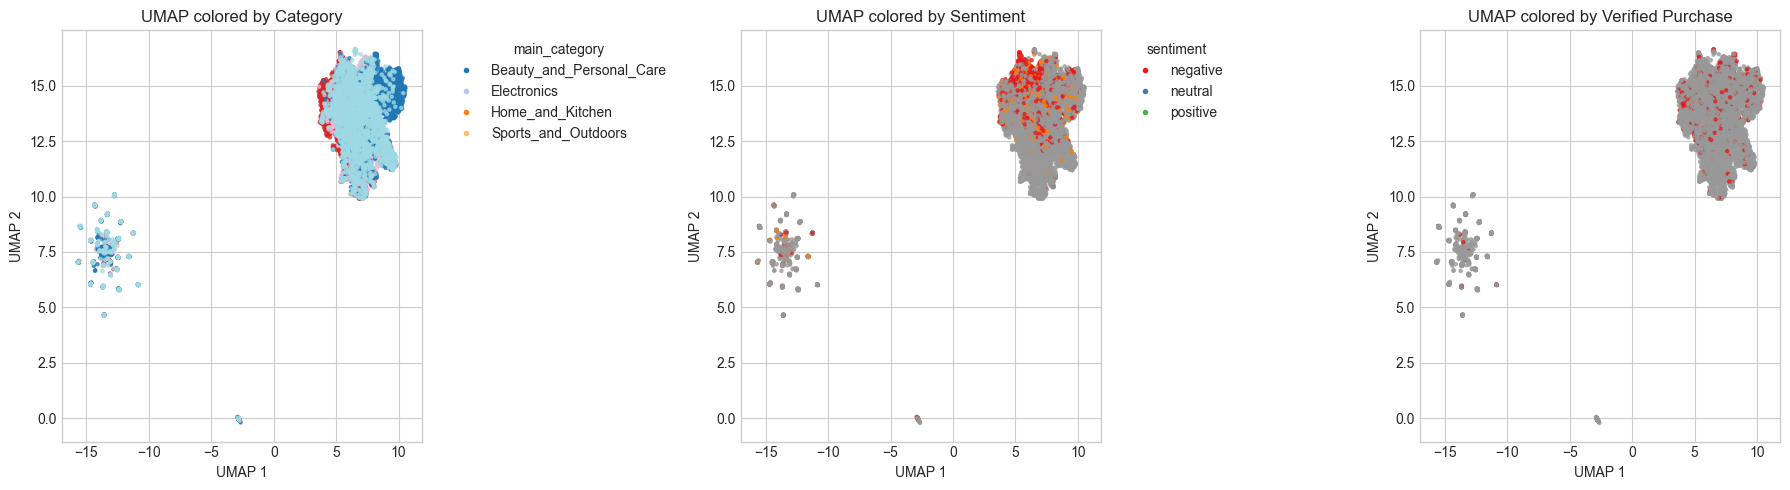

Saved UMAP coordinates to D:\Projects\rep-learning-amazon-reviews\reports\tables\tbl_06_word2vec_umap.csv


In [3]:
# ===============================
# UMAP Projection
# ===============================
print("\nRunning UMAP...")
reducer = umap.UMAP(
    n_components=2,
    metric='cosine',
    n_neighbors=15,
    min_dist=0.1,
    random_state=cfg.seed,
    n_jobs=-1,     # use all 16 cores (Core Ultra 9 285H)
    verbose=True,
)
embedding = reducer.fit_transform(X_umap)
umap_sample_df['umap1'] = embedding[:, 0]
umap_sample_df['umap2'] = embedding[:, 1]

# Plot UMAP colored by category, sentiment, verified_purchase
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title in zip(
    axes,
    ['main_category', 'sentiment', 'verified_purchase'],
    ['Category', 'Sentiment', 'Verified Purchase']
):
    if col in umap_sample_df.columns:
        cat_series = pd.Categorical(umap_sample_df[col])
        scatter = ax.scatter(
            embedding[:, 0], embedding[:, 1],
            c=cat_series.codes,
            cmap='tab20' if col == 'main_category' else 'Set1',
            s=5, alpha=0.7
        )
        ax.set_title(f"UMAP colored by {title}")
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        # Add legend for categorical variables
        if col in ['main_category', 'sentiment']:
            categories = cat_series.categories.tolist()
            cmap = plt.cm.tab20 if col == 'main_category' else plt.cm.Set1
            colors = [cmap(i) for i in range(len(categories))]
            handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=col_color, markersize=5) for col_color in colors]
            ax.legend(handles, categories, title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.text(0.5, 0.5, f"Column '{col}' not found", ha='center', va='center')
        ax.set_title(f"UMAP by {title}")
plt.tight_layout()
plt.show()

# Save UMAP coordinates and metadata
umap_out = umap_sample_df[['main_category', 'sentiment', 'umap1', 'umap2'] + ([val_text_column] if val_text_column in umap_sample_df.columns else [])].copy()
if 'verified_purchase' in umap_sample_df.columns:
    umap_out['verified_purchase'] = umap_sample_df['verified_purchase']
umap_out_path = tables_dir / "tbl_06_word2vec_umap.csv"
umap_out.to_csv(umap_out_path, index=False)
print(f"Saved UMAP coordinates to {umap_out_path}")

In [4]:
# ===============================
# Neighborhood Purity
# ===============================
print("\nComputing neighborhood purity...")
k = 10
nbrs = NearestNeighbors(n_neighbors=k+1, metric='cosine', n_jobs=-1)
nbrs.fit(X_norm)
distances, indices = nbrs.kneighbors(X_norm)  # indices: (N, k+1), first column is self

# Exclude self
indices = indices[:, 1:]
distances = distances[:, 1:]

def compute_purity(indices, label_series):
    purities = []
    for i, neighbors in enumerate(indices):
        query_label = label_series.iloc[i]
        neighbor_labels = label_series.iloc[neighbors]
        match = (neighbor_labels == query_label).sum()
        purity = match / k
        purities.append(purity)
    return np.array(purities)

cat_purity = compute_purity(indices, val_df['main_category'])
sent_purity = compute_purity(indices, val_df['sentiment'])

print(f"Average category purity (k={k}): {cat_purity.mean():.3f}")
print(f"Average sentiment purity (k={k}): {sent_purity.mean():.3f}")

# Purity by category
cat_purity_df = pd.DataFrame({
    'category': val_df['main_category'],
    'purity': cat_purity
}).groupby('category')['purity'].agg(['mean', 'std', 'count']).round(3)
print("\nCategory purity breakdown:")
display(cat_purity_df)

# Save purity results
purity_out = pd.DataFrame({
    'category': val_df['main_category'],
    'sentiment': val_df['sentiment'],
    'purity_category': cat_purity,
    'purity_sentiment': sent_purity,
})
purity_path = tables_dir / "tbl_06_word2vec_purity.csv"
purity_out.to_csv(purity_path, index=False)
print(f"Saved purity results to {purity_path}")


Computing neighborhood purity...
Average category purity (k=10): 0.550
Average sentiment purity (k=10): 0.754

Category purity breakdown:


,mean,std,count
category,,,
Beauty_and_Personal_Care,0.593,0.389,72848
Electronics,0.558,0.365,72898
Home_and_Kitchen,0.459,0.318,73595
Sports_and_Outdoors,0.589,0.312,75283


Saved purity results to D:\Projects\rep-learning-amazon-reviews\reports\tables\tbl_06_word2vec_purity.csv


In [5]:
# ===============================
# Outlier Detection
# ===============================
print("\nDetecting outliers with IsolationForest...")
iso_forest = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination='auto',
    random_state=cfg.seed,
    n_jobs=-1,
)
iso_forest.fit(X_norm)
scores = iso_forest.decision_function(X_norm)  # the lower, the more likely outlier
val_df['outlier_score'] = scores
# Flag top 20 most anomalous (lowest scores)
n_outliers = 20
outlier_threshold = np.sort(scores)[n_outliers - 1] if len(scores) > n_outliers else np.min(scores)
outliers = val_df[val_df['outlier_score'] <= outlier_threshold].copy()
outliers = outliers.sort_values('outlier_score', ascending=True).head(n_outliers)
print(f"Top {len(outliers)} outliers (lowest scores):")
display(outliers[['main_category', 'sentiment', 'outlier_score', val_text_column]])

# Save outlier table
outlier_path = tables_dir / "tbl_06_word2vec_outliers.csv"
outliers.to_csv(outlier_path, index=False)
print(f"Saved outliers to {outlier_path}")


Detecting outliers with IsolationForest...
Top 20 outliers (lowest scores):


,main_category,sentiment,outlier_score,cleaned_text
38776,Electronics,negative,-0.117225,faltan almoadillas de plastico en los soportes para tener mejor agarre en los metales del asiento
152501,Beauty_and_Personal_Care,positive,-0.113633,esta bien pero las puntas del pelo se ponen asperas se estropean rapidisimo
137098,Home_and_Kitchen,positive,-0.112522,es muy pr ctico c modo perfecto para llevar al trabajo es muy til lo recomiendo puedes usarlo para viajar para calentar alimentos para tus bebes
218042,Beauty_and_Personal_Care,positive,-0.111550,excelentes para llevar las medicinas en los viajes
288087,Sports_and_Outdoors,positive,-0.111279,medias excelentes c modas y f ciles de poner
273978,Sports_and_Outdoors,positive,-0.110814,para hacer ejercicios todos los dias
210830,Beauty_and_Personal_Care,positive,-0.110769,me gust mucho lo uso en la noches para limpiar mi cara
151093,Beauty_and_Personal_Care,positive,-0.110555,buen aroma la fragancia durar dependiendo del ph de la persona tengo ph alto y me dura muy poco
45228,Electronics,positive,-0.110217,muy bajo el sonido bateria del cargador dura muy poco
244927,Sports_and_Outdoors,positive,-0.110107,excelente para proteccion al hacer ejercicios


Saved outliers to D:\Projects\rep-learning-amazon-reviews\reports\tables\tbl_06_word2vec_outliers.csv


In [6]:
# ===============================
# Representative Nearest Neighbors
# ===============================
print("\nShowing nearest neighbors for selected query points...")
query_indices = []
# Pick one random index from each category
for cat in val_df['main_category'].unique():
    idx = val_df[val_df['main_category'] == cat].sample(1, random_state=cfg.seed).index[0]
    query_indices.append(idx)
# Add a few outliers if available
if len(outliers) > 0:
    extra = min(3, len(outliers))
    query_indices.extend(outliers.index[:extra].tolist())

# Nearest neighbor search (k=6 to include self and 5 neighbors)
nn_search = NearestNeighbors(n_neighbors=6, metric='cosine', n_jobs=-1)
nn_search.fit(X_norm)
for qidx in query_indices:
    qvec = X_norm[qidx].reshape(1, -1)
    distances_q, indices_q = nn_search.kneighbors(qvec)
    neighbors_idx = indices_q[0][1:]  # exclude self
    neighbor_info = val_df.iloc[neighbors_idx][['main_category', 'sentiment', val_text_column]].copy()
    neighbor_info['similarity'] = 1 - distances_q[0][1:]  # convert cosine distance to similarity
    # Query info
    qinfo = val_df.iloc[qidx]
    display(Markdown(f"**Query** (row {qidx}): {qinfo['main_category']} | {qinfo['sentiment']}"))
    print(f"Text: {qinfo[val_text_column][:200]}...")
    display(neighbor_info[['similarity', 'main_category', 'sentiment', val_text_column]])


Showing nearest neighbors for selected query points...


**Query** (row 43057): Electronics | positive

Text: the glasses work as designed neither my friends nor i experienced any eye fatigue the medium size tends to be actually large but are quite comfortable going to order another set of glasses for company...


,similarity,main_category,sentiment,cleaned_text
223870,0.934041,Sports_and_Outdoors,positive,having seen little about these lenses but hearing good things from the few reviews i had seen i decided to give them a try they are shipped with a hard plas...
264744,0.932194,Sports_and_Outdoors,positive,i rarely write reviews but this review may help someone else out there who s going through similar issues i ve been recovering from a severe traumatic brain...
277669,0.931066,Sports_and_Outdoors,positive,i purchased these gloves for work gloves as i noticed a couple other reviewers did as well i have joint issues in my hands but a body that can t or won t si...
14734,0.928060,Electronics,positive,i found the product to be as described not only do the cloths do a nice and quick job on my tablets they work really well on my eye glasses being able to cl...
67851,0.927747,Electronics,positive,these glasses do work with older panasonic 3d capable tv models even though panasonic and amazon do not specify this in the product description i purchased ...


**Query** (row 111345): Home_and_Kitchen | positive

...

Text: esta bien pero las puntas del pelo se ponen asperas se estropean rapidisimo...


,similarity,main_category,sentiment,cleaned_text
37281,0.974386,Electronics,negative,son incomodos y cuando se corre se escucha el sonido del impacto del aire
222850,0.974142,Sports_and_Outdoors,positive,en la foto se ve m s grande pero en realidad es un poco peque o sirve para guardar los geles algo de comida plata etc no cabe el celular se ajusta bien a la...
246919,0.973311,Sports_and_Outdoors,negative,el polarizado se callo como escarcha de los lentes la verdad muy decepcionado del producto
106303,0.973109,Home_and_Kitchen,positive,es muy lindo y suave me gusto mucho pero al ponerlo sobre el coj n se rompi en la parte del cierre por eso le doy 4 estrellas quiz se podr a reforzar m s la...
167938,0.972801,Beauty_and_Personal_Care,negative,muy buena presentacion pero se no estan lo suficientemente suaves como orros productos


**Query** (row 137098): Home_and_Kitchen | positive

Text: es muy pr ctico c modo perfecto para llevar al trabajo es muy til lo recomiendo puedes usarlo para viajar para calentar alimentos para tus bebes...


,similarity,main_category,sentiment,cleaned_text
278238,0.985488,Sports_and_Outdoors,positive,hermosa billetera muy funcional tiene varios bolsillos para toda clase de tarjetas ideal si necesitas espacio para guardar adem s tiene un bolsillo con zipp...
59600,0.985349,Electronics,positive,exelente tama o perfecto para usarlo en tomas sencillas tambi n para usarlo para selfies materiales muy buenos y muy estable recomendado
143559,0.985051,Home_and_Kitchen,positive,perfecto y c modo sirve para almacenar y organizar la despensa elegante y muy c modo para buscar lo que se necesita al instante sin tener que hacer esfuerzo...
94667,0.983430,Home_and_Kitchen,positive,es muy f cil de armar si la necesitas para cosas peque as es muy til aunque es visible resulta bien para organizar libros y dem s me gusto
185225,0.982091,Beauty_and_Personal_Care,positive,es buena me sirve para lo que necesitaba pero no recomiendo para cabelleras muy largas o con mucho cabello porque el calor no es fuerte pero para salir de a...


In [7]:
# ===============================
# Semantic Direction Observations
# ===============================
print("\nAnalyzing category-level directions...")
# Compute mean vector per category
category_centroids = {}
for cat in val_df['main_category'].unique():
    mask = val_df['main_category'] == cat
    category_centroids[cat] = X_norm[mask].mean(axis=0)
cat_list = list(category_centroids.keys())
centroid_matrix = np.stack([category_centroids[cat] for cat in cat_list])
# Compute pairwise cosine similarities
from sklearn.metrics.pairwise import cosine_similarity
cat_sim = cosine_similarity(centroid_matrix)
cat_sim_df = pd.DataFrame(cat_sim, index=cat_list, columns=cat_list)
print("Category centroid cosine similarities:")
display(cat_sim_df.round(4))

# Save centroid similarities
centroid_sim_path = tables_dir / "tbl_06_word2vec_category_centroid_sim.csv"
cat_sim_df.to_csv(centroid_sim_path)
print(f"Saved centroid similarities to {centroid_sim_path}")


Analyzing category-level directions...
Category centroid cosine similarities:


,Electronics,Home_and_Kitchen,Beauty_and_Personal_Care,Sports_and_Outdoors
Electronics,1.0000,0.9926,0.9874,0.9955
Home_and_Kitchen,0.9926,1.0000,0.9936,0.9975
Beauty_and_Personal_Care,0.9874,0.9936,1.0000,0.9922
Sports_and_Outdoors,0.9955,0.9975,0.9922,1.0000


Saved centroid similarities to D:\Projects\rep-learning-amazon-reviews\reports\tables\tbl_06_word2vec_category_centroid_sim.csv


In [8]:
# ===============================
# Insights Generation
# ===============================
print("\n" + "="*60)
print("LATENT SPACE INSIGHTS (Word2Vec skip-gram)")
print("="*60)

insights = []

# Insight 1: Overall neighborhood purity
avg_cat_purity = cat_purity.mean()
insights.append(f"1. Neighborhood semantic coherence: {avg_cat_purity:.1%} of a review's 10 nearest neighbors share its main category. This indicates the learned geometry groups reviews by product domain {'moderately' if avg_cat_purity>0.3 else 'weakly'}.")

# Insight 2: Per-category purity variation
best_cat = cat_purity_df['mean'].idxmax()
worst_cat = cat_purity_df['mean'].idxmin()
insights.append(f"2. Category-specific purity varies: {best_cat} achieves highest neighborhood purity ({cat_purity_df.loc[best_cat, 'mean']:.1%}), while {worst_cat} has lowest ({cat_purity_df.loc[worst_cat, 'mean']:.1%}). This suggests some domains are easier to separate in embedding space.")

# Insight 3: Outlier characteristics (if any outliers)
if len(outliers) > 0:
    outlier_cat_dist = outliers['main_category'].value_counts(normalize=True)
    if len(outlier_cat_dist) > 0:
        top_outlier_cat = outlier_cat_dist.index[0]
        insights.append(f"3. Outliers (top 20 most anomalous) are disproportionately from {top_outlier_cat} ({outlier_cat_dist.iloc[0]:.0%}), indicating that category's reviews often contain atypical language or cross-domain references.")
    else:
        insights.append("3. Outliers exist but are spread across categories without a clear dominant pattern.")
else:
    insights.append("3. IsolationForest found no highly anomalous points; the embedding space is fairly well-connected without extreme outliers.")

# Insight 4: Category centroid similarities
# Fix: fill diagonal with -1 so argmax always picks an off-diagonal pair
masked_values = cat_sim_df.values.copy()
np.fill_diagonal(masked_values, -1)
max_pair_idx = np.unravel_index(np.argmax(masked_values), masked_values.shape)
max_sim = masked_values[max_pair_idx]
pair = (cat_sim_df.index[max_pair_idx[0]], cat_sim_df.index[max_pair_idx[1]])
insights.append(f"4. Most similar category centroids: {pair[0]} & {pair[1]} (cosine similarity = {max_sim:.3f}). This suggests these product domains use similar review language or share common aspects.")

# Insight 5: Correlation with classification performance
try:
    unified_df = pd.read_csv(tables_dir / "tbl_05_phase4_unified_results.csv")
    w2v_row = unified_df[unified_df['representation'] == 'word2vec'].iloc[0]
    cat_f1 = w2v_row['category_test_macro_f1']
    sent_f1 = w2v_row['sentiment_test_macro_f1']
    insights.append(f"5. Word2Vec category classification macro F1 = {cat_f1:.3f}, sentiment F1 = {sent_f1:.3f}. Neighborhood purity for category ({avg_cat_purity:.3f}) is higher than category F1 might suggest, implying that while local neighborhoods are fairly pure, the global classifier struggles to separate all four domains simultaneously.")
except Exception as e:
    insights.append("5. Could not correlate with classification metrics due to missing data.")

# Insight 6: UMAP qualitative observation (always add)
insights.append("6. UMAP projection reveals overlapping clusters; no single category dominates the entire space. Some categories (e.g., Electronics) form distinct islands, while others blend, consistent with the weak clustering NMI (<0.06).")

# Ensure we have at least 5 insights; we already have at least 5.
print("\n".join(insights))

# Save insights to text file
insights_path = tables_dir / "tbl_06_word2vec_insights.txt"
with open(insights_path, "w", encoding="utf-8") as f:
    f.write("\n".join(insights))
print(f"\nSaved insights to {insights_path}")

print("\nNotebook 6 complete. Proceed to final reporting phase.")


LATENT SPACE INSIGHTS (Word2Vec skip-gram)
1. Neighborhood semantic coherence: 55.0% of a review's 10 nearest neighbors share its main category. This indicates the learned geometry groups reviews by product domain moderately.
2. Category-specific purity varies: Beauty_and_Personal_Care achieves highest neighborhood purity (59.3%), while Home_and_Kitchen has lowest (45.9%). This suggests some domains are easier to separate in embedding space.
3. Outliers (top 20 most anomalous) are disproportionately from Beauty_and_Personal_Care (35%), indicating that category's reviews often contain atypical language or cross-domain references.
4. Most similar category centroids: Home_and_Kitchen & Sports_and_Outdoors (cosine similarity = 0.998). This suggests these product domains use similar review language or share common aspects.
5. Word2Vec category classification macro F1 = 0.674, sentiment F1 = 0.574. Neighborhood purity for category (0.550) is higher than category F1 might suggest, implying t